# Демо: Предобработка данных и Feature Engineering

Этот ноутбук показывает **концепции** предобработки.  
В вашей лабораторной — полный датасет и все этапы самостоятельно.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 0
sns.set_theme(style='whitegrid')

df = pd.read_csv('diabetes_demo.csv')
print(f'Размер: {df.shape}')
df.head()

Размер: (200, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## 1. EDA — быстрый взгляд на данные

In [2]:
# Базовая статистика
df.describe().round(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0
mean,4.2,118.6,69.1,20.0,74.8,31.8,0.5,33.2,0.4
std,3.4,32.7,19.3,16.3,117.3,9.0,0.3,11.0,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,63.5,0.0,0.0,27.4,0.2,24.0,0.0
50%,4.0,113.5,72.0,23.0,0.0,32.0,0.4,30.5,0.0
75%,7.0,141.0,80.0,33.0,114.2,36.6,0.6,40.0,1.0
max,17.0,197.0,122.0,60.0,846.0,67.1,2.3,69.0,1.0


In [3]:
# Обратите внимание: минимум у Glucose, BloodPressure, BMI — ноль.
# Физиологически это невозможно. Что это значит?
print('Нулевые значения:')
zero_suspect = ['Glucose', 'BloodPressure', 'BMI']
for col in zero_suspect:
    print(f'  {col}: {(df[col] == 0).sum()} нулей')

Нулевые значения:
  Glucose: 2 нулей
  BloodPressure: 8 нулей
  BMI: 5 нулей


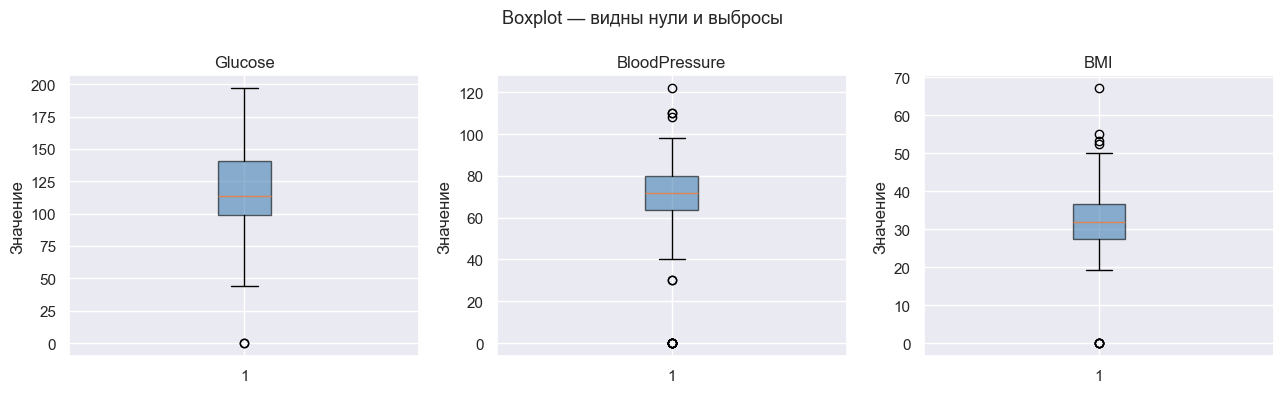

In [4]:
# Как выглядит распределение? Boxplot сразу показывает и выбросы, и нули
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, zero_suspect):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Значение')

plt.suptitle('Boxplot — видны нули и выбросы', fontsize=13)
plt.tight_layout()
plt.show()

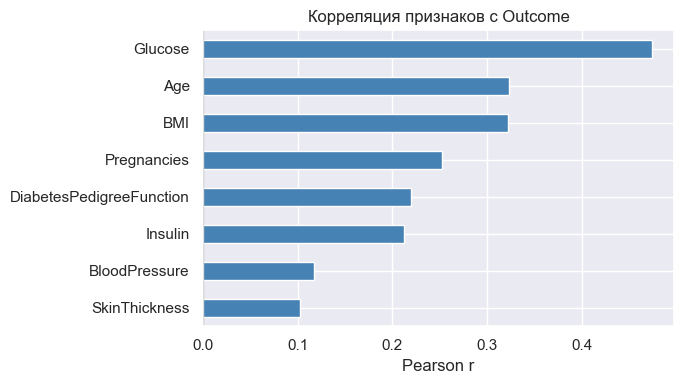

In [5]:
# Корреляция с целевой переменной
corr_with_target = df.corr()['Outcome'].drop('Outcome').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Корреляция признаков с Outcome')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

# Вопрос студентам: какой признак наиболее информативен?

---
## 2. Feature Engineering — создаём новые признаки

Идея: сырые числа → осмысленные категории и взаимодействия между признаками.

In [6]:
df_fe = df.copy()

# ── Пример 1: категоризация числового признака ──────────────────────────────
# Вместо просто «возраст» — возрастная группа
# (в вашей лабе: категоризуйте другие признаки по медицинским стандартам)

df_fe['AgeGroup'] = pd.cut(
    df_fe['Age'],
    bins=[0, 30, 50, 200],
    labels=['young', 'mature', 'senior']
)

print('Распределение по возрастным группам:')
print(df_fe['AgeGroup'].value_counts())

Распределение по возрастным группам:
AgeGroup
young     100
mature     81
senior     19
Name: count, dtype: int64


In [7]:
# ── Пример 2: взаимодействие признаков (interaction feature) ────────────────
# Произведение двух признаков — нелинейная связь, которую модель сама не видит
# В вашей лабе — Glucose×Insulin, BMI×Age и др.

df_fe['Preg_Age_ratio'] = df_fe['Pregnancies'] / (df_fe['Age'] + 1)  # +1 чтобы не делить на 0

print('Новый признак Preg_Age_ratio (первые 5 строк):')
print(df_fe[['Pregnancies', 'Age', 'Preg_Age_ratio']].head())

Новый признак Preg_Age_ratio (первые 5 строк):
   Pregnancies  Age  Preg_Age_ratio
0            6   50        0.117647
1            1   31        0.031250
2            8   32        0.242424
3            1   21        0.045455
4            0   33        0.000000


In [8]:
# ── Пример 3: бинарный флаг ─────────────────────────────────────────────────
# Медицинский порог → бинарный признак
# (в вашей лабе — нормальный/аномальный инсулин по диапазону 16-166)

df_fe['HighGlucose'] = (df_fe['Glucose'] >= 140).astype(int)

print('HighGlucose vs Outcome (средняя частота диабета):')
print(df_fe.groupby('HighGlucose')['Outcome'].mean().round(3))
# Должна быть заметная разница — иначе признак бесполезен

HighGlucose vs Outcome (средняя частота диабета):
HighGlucose
0    0.289
1    0.627
Name: Outcome, dtype: float64


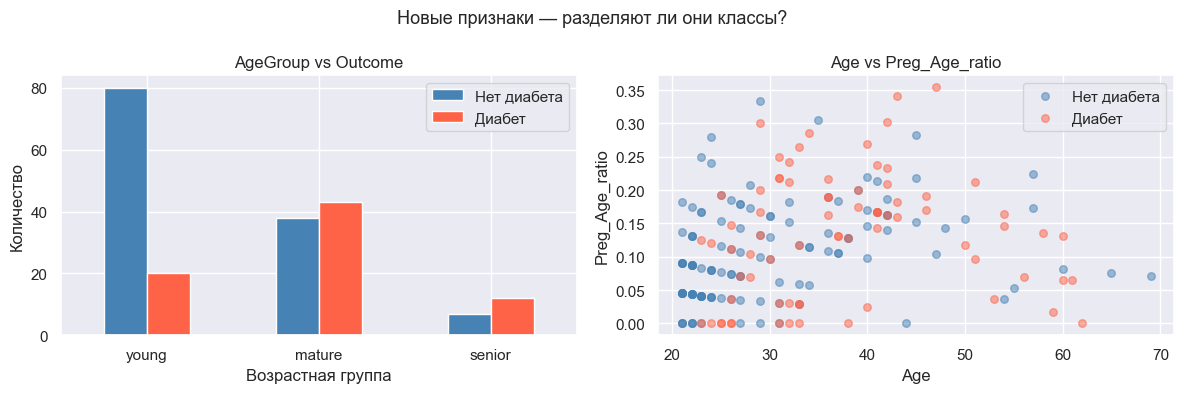

In [9]:
# Визуализация: насколько новые признаки разделяют классы?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Новый категориальный признак
ct = df_fe.groupby(['AgeGroup', 'Outcome'], observed=True).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('AgeGroup vs Outcome')
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('Количество')
axes[0].legend(['Нет диабета', 'Диабет'])
axes[0].tick_params(axis='x', rotation=0)

# Interaction feature vs сырой Age
for outcome, color, label in [(0, 'steelblue', 'Нет диабета'), (1, 'tomato', 'Диабет')]:
    subset = df_fe[df_fe['Outcome'] == outcome]
    axes[1].scatter(subset['Age'], subset['Preg_Age_ratio'],
                    alpha=0.5, color=color, label=label, s=30)
axes[1].set_title('Age vs Preg_Age_ratio')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Preg_Age_ratio')
axes[1].legend()

plt.suptitle('Новые признаки — разделяют ли они классы?', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Pipeline — собираем всё вместе

Главная идея: **fit только на train**, transform применяем к test.  
Иначе — data leakage.

In [10]:
# Определяем типы признаков
X = df_fe.drop('Outcome', axis=1)
y = df_fe['Outcome']

num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
            'DiabetesPedigreeFunction', 'Age', 'Preg_Age_ratio', 'HighGlucose']
cat_cols = ['AgeGroup']  # мультиклассовый → OHE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (160, 11)  |  Test: (40, 11)


In [11]:
# Строим pipeline
# ColumnTransformer применяет разные преобразования к разным столбцам

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

# Весь пайплайн — один вызов fit/predict
pipeline.fit(X_train, y_train)
score = pipeline.score(X_test, y_test)
print(f'Accuracy на тесте: {score:.3f}')

Accuracy на тесте: 0.750


In [12]:
# Почему Pipeline важен? Покажем на примере data leakage

print('=== БЕЗ Pipeline (data leakage) ===')
scaler_bad = StandardScaler()
# ОШИБКА: scaler видит весь датасет до сплита
X_scaled_bad = scaler_bad.fit_transform(X[num_cols])  
print('Scaler обучен на ВСЕХ данных — тестовая информация утекла в train!')

print()
print('=== С Pipeline (правильно) ===')
# fit_transform только на X_train, transform на X_test
print('Scaler обучается только на train — тест остаётся чистым ✓')

=== БЕЗ Pipeline (data leakage) ===
Scaler обучен на ВСЕХ данных — тестовая информация утекла в train!

=== С Pipeline (правильно) ===
Scaler обучается только на train — тест остаётся чистым ✓


---
## Итог

| Концепция | Что делает | Зачем |
|-----------|-----------|-------|
| `pd.cut` | числа → категории | интерпретируемость, медицинские пороги |
| interaction feature | `A * B` или `A / B` | нелинейные зависимости |
| бинарный флаг | 0/1 по порогу | явный медицинский смысл |
| `ColumnTransformer` | разные трансформации по столбцам | числа ≠ категории |
| `Pipeline` | fit только на train | защита от data leakage |

> **Задание:** в вашей лабе — полный датасет (768 строк), минимум 5 новых признаков,  
> обработка пропусков, capping выбросов, сравнение метрик до/после.